# Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset using pandas dataframe

In [2]:
dataset = pd.read_csv('Salary_Data_larger.csv')
dataset.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
dataset.shape

(6704, 6)

### Checking dataset type and various info

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 552.7 KB


In [5]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


## checking for missing values as they can worsen the predictions and hamper in model training

In [6]:
missing_data = dataset.isnull().sum()
print(missing_data)

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [7]:
dataset.dropna(inplace=True)

In [8]:
missing_data = dataset.isnull().sum()
print(missing_data)

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


### Creating a copy of the main dataset -> not necessary but makes it flexible to work and fix issues

In [9]:
dataset_copy = dataset.copy()

dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


### Converting object types to string so that ML model can work -> most models need int/float only but as I am using CatBoost, it can work with string, float, and interger types.

In [10]:
dataset_copy["Gender"] = dataset_copy["Gender"].astype("string")
dataset_copy["Education Level"] = dataset_copy["Education Level"].astype("string")
dataset_copy["Job Title"] = dataset_copy["Job Title"].astype("string")

In [11]:
dataset_copy.dtypes

Age                    float64
Gender                  string
Education Level         string
Job Title               string
Years of Experience    float64
Salary                 float64
dtype: object

### Checking for duplicate values in the dataset as they can give exceptional training performance and worse testing results.

In [12]:
dataset_copy.duplicated().sum()

np.int64(4911)

In [13]:
dataset_copy = dataset_copy.drop_duplicates()

In [14]:
dataset_copy.duplicated().sum()

np.int64(0)

### Simplifying the string values for the model

In [15]:
dataset_copy["Gender"] = dataset_copy["Gender"].str.lower().str.strip()
dataset_copy["Education Level"] = dataset_copy["Education Level"].str.lower().str.strip()
dataset_copy["Job Title"] = dataset_copy["Job Title"].str.lower().str.strip()

In [16]:
dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,bachelor's,software engineer,5.0,90000.0
1,28.0,female,master's,data analyst,3.0,65000.0
2,45.0,male,phd,senior manager,15.0,150000.0
3,36.0,female,bachelor's,sales associate,7.0,60000.0
4,52.0,male,master's,director,20.0,200000.0


### Here, I am fixing the education level columns value's as they are a bit irregular. For easier model understanding cleaning is done here.

In [17]:
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("phd","PhD")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("master's degree","Master")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("master's","Master")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("bachelor's degree","Bachelor")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("bachelor's","Bachelor")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("high school","High School")

In [18]:
dataset_copy.shape

(1787, 6)

### Final veiw of the dataset before feeding the data inside model

In [19]:
dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,Bachelor,software engineer,5.0,90000.0
1,28.0,female,Master,data analyst,3.0,65000.0
2,45.0,male,PhD,senior manager,15.0,150000.0
3,36.0,female,Bachelor,sales associate,7.0,60000.0
4,52.0,male,Master,director,20.0,200000.0


## Dataset split for model training (single split checking)

In [20]:
x = dataset_copy.drop(columns=["Salary"])
y = dataset_copy["Salary"]

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Importing catboost model and assigning the categorical columns

In [22]:
from catboost import CatBoostRegressor

cat_features = ["Gender", "Education Level", "Job Title"]

### Default CatBoostRegressor model is used.

In [23]:
model = CatBoostRegressor()

In [24]:
model.fit(
    x_train,
    y_train,
    cat_features=cat_features,
    verbose=100
)

Learning rate set to 0.043319


0:	learn: 49831.4902915	total: 56.9ms	remaining: 56.8s
100:	learn: 18017.7845262	total: 128ms	remaining: 1.14s
200:	learn: 15811.4394141	total: 177ms	remaining: 703ms


300:	learn: 14480.7059105	total: 225ms	remaining: 523ms


400:	learn: 13550.8980290	total: 274ms	remaining: 409ms
500:	learn: 12826.3757906	total: 324ms	remaining: 323ms
600:	learn: 12188.6012288	total: 381ms	remaining: 253ms


700:	learn: 11711.7311553	total: 430ms	remaining: 183ms


800:	learn: 11227.6695465	total: 501ms	remaining: 125ms
900:	learn: 10840.3066758	total: 555ms	remaining: 61ms
999:	learn: 10463.4348396	total: 606ms	remaining: 0us


CatBoostRegressor(loss_function='RMSE')

In [25]:
predictions = model.predict(x_test)

### Performance measurement of the model

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(r2_score(y_test, predictions))
print(mean_absolute_error(y_test, predictions))
print(mean_squared_error(y_test, predictions))

0.8983603428550143


11576.081469158866
278486593.41453946


### Input function for manual testing

In [27]:
def predict_salary(age, gender, education, job_title, experience):
    
    
    user_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender.lower().strip()],
        "Education Level": [education],
        "Job Title": [job_title.lower().strip()],
        "Years of Experience": [experience]
    })
    
    prediction = model.predict(user_data)[0]
    
    return round(prediction, 2)

In [28]:
# use it for making predictions 

predict_salary(
    age=46,
    gender="Male",
    education="PhD",  # Bachelor, Master, PhD
    job_title="Manager",
    experience=2
)

np.float64(58072.63)

### SHAP Analysis -> it shows what's in the dataset is responsible for prediction

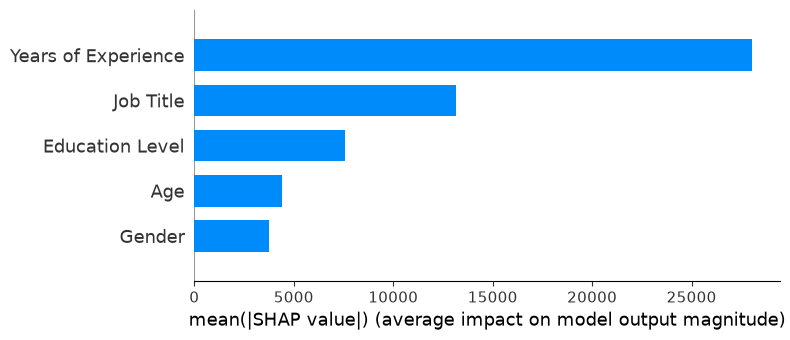

In [29]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test, plot_type="bar")

### Cross validation for checking model's performance on the entire dataset (better than single split analysis)

In [30]:
from catboost import Pool, cv

cat_features = ["Gender", "Education Level", "Job Title"]

# using 5-fold --> 4 fold contains data for training and 1 fold for testing, and repeats 5 times 
# --> so that all data gets used for both training and testing across the folds
train_pool = Pool(
    data=dataset_copy.drop("Salary", axis=1), 
    label=dataset_copy["Salary"],
    cat_features=cat_features
)

cv_results = cv(
    pool=train_pool,
    params={
        "loss_function": "RMSE",   
        "eval_metric": "R2"       
    },
    fold_count=5
)

print(cv_results.tail())

Training on fold [0/5]
0:	learn: -4.4662384	test: -4.6506262	best: -4.6506262 (0)	total: 1.65ms	remaining: 1.65s
1:	learn: -4.1776598	test: -4.3432323	best: -4.3432323 (1)	total: 3.16ms	remaining: 1.58s
2:	learn: -3.9143339	test: -4.0668484	best: -4.0668484 (2)	total: 4.27ms	remaining: 1.42s
3:	learn: -3.6548841	test: -3.7913195	best: -3.7913195 (3)	total: 5.94ms	remaining: 1.48s
4:	learn: -3.4075624	test: -3.5397832	best: -3.5397832 (4)	total: 7.7ms	remaining: 1.53s
5:	learn: -3.1767456	test: -3.2998139	best: -3.2998139 (5)	total: 9.22ms	remaining: 1.53s
6:	learn: -2.9702699	test: -3.0837663	best: -3.0837663 (6)	total: 11.9ms	remaining: 1.68s
7:	learn: -2.7740091	test: -2.8809977	best: -2.8809977 (7)	total: 12.4ms	remaining: 1.54s
8:	learn: -2.5892142	test: -2.6895248	best: -2.6895248 (8)	total: 12.7ms	remaining: 1.4s
9:	learn: -2.3977998	test: -2.4939126	best: -2.4939126 (9)	total: 14.4ms	remaining: 1.43s
10:	learn: -2.2280847	test: -2.3204019	best: -2.3204019 (10)	total: 15.8ms	rema

171:	learn: 0.8736174	test: 0.8581331	best: 0.8581331 (171)	total: 193ms	remaining: 929ms
172:	learn: 0.8741283	test: 0.8586133	best: 0.8586133 (172)	total: 194ms	remaining: 927ms
173:	learn: 0.8745380	test: 0.8588522	best: 0.8588522 (173)	total: 195ms	remaining: 923ms
174:	learn: 0.8753541	test: 0.8594855	best: 0.8594855 (174)	total: 195ms	remaining: 920ms
175:	learn: 0.8756738	test: 0.8598538	best: 0.8598538 (175)	total: 196ms	remaining: 916ms
176:	learn: 0.8759219	test: 0.8600712	best: 0.8600712 (176)	total: 197ms	remaining: 916ms
177:	learn: 0.8765732	test: 0.8602965	best: 0.8602965 (177)	total: 197ms	remaining: 912ms
178:	learn: 0.8768146	test: 0.8605729	best: 0.8605729 (178)	total: 198ms	remaining: 908ms
179:	learn: 0.8768740	test: 0.8605900	best: 0.8605900 (179)	total: 198ms	remaining: 904ms
180:	learn: 0.8773225	test: 0.8610973	best: 0.8610973 (180)	total: 200ms	remaining: 904ms
181:	learn: 0.8780828	test: 0.8616228	best: 0.8616228 (181)	total: 200ms	remaining: 900ms
182:	learn

361:	learn: 0.9169344	test: 0.8875748	best: 0.8875748 (361)	total: 387ms	remaining: 681ms
362:	learn: 0.9170907	test: 0.8877870	best: 0.8877870 (362)	total: 387ms	remaining: 679ms
363:	learn: 0.9171957	test: 0.8878013	best: 0.8878013 (363)	total: 389ms	remaining: 680ms
364:	learn: 0.9173235	test: 0.8878118	best: 0.8878118 (364)	total: 391ms	remaining: 680ms
365:	learn: 0.9174544	test: 0.8879541	best: 0.8879541 (365)	total: 392ms	remaining: 679ms
366:	learn: 0.9177261	test: 0.8880967	best: 0.8880967 (366)	total: 393ms	remaining: 678ms
367:	learn: 0.9177540	test: 0.8880932	best: 0.8880967 (366)	total: 395ms	remaining: 678ms
368:	learn: 0.9178844	test: 0.8882482	best: 0.8882482 (368)	total: 396ms	remaining: 677ms
369:	learn: 0.9179637	test: 0.8882697	best: 0.8882697 (369)	total: 397ms	remaining: 677ms
370:	learn: 0.9180887	test: 0.8883796	best: 0.8883796 (370)	total: 398ms	remaining: 675ms
371:	learn: 0.9181621	test: 0.8884557	best: 0.8884557 (371)	total: 399ms	remaining: 673ms
372:	learn

527:	learn: 0.9329700	test: 0.8930712	best: 0.8931828 (521)	total: 581ms	remaining: 520ms
528:	learn: 0.9330575	test: 0.8930361	best: 0.8931828 (521)	total: 583ms	remaining: 519ms
529:	learn: 0.9331648	test: 0.8929922	best: 0.8931828 (521)	total: 584ms	remaining: 518ms
530:	learn: 0.9333314	test: 0.8929997	best: 0.8931828 (521)	total: 584ms	remaining: 516ms
531:	learn: 0.9334609	test: 0.8930466	best: 0.8931828 (521)	total: 586ms	remaining: 515ms
532:	learn: 0.9335069	test: 0.8929895	best: 0.8931828 (521)	total: 587ms	remaining: 514ms
533:	learn: 0.9335468	test: 0.8929878	best: 0.8931828 (521)	total: 589ms	remaining: 514ms
534:	learn: 0.9337003	test: 0.8930861	best: 0.8931828 (521)	total: 590ms	remaining: 513ms
535:	learn: 0.9338310	test: 0.8931097	best: 0.8931828 (521)	total: 591ms	remaining: 512ms
536:	learn: 0.9338707	test: 0.8931360	best: 0.8931828 (521)	total: 593ms	remaining: 511ms
537:	learn: 0.9340365	test: 0.8933023	best: 0.8933023 (537)	total: 593ms	remaining: 509ms
538:	learn

697:	learn: 0.9431550	test: 0.8951196	best: 0.8951196 (697)	total: 776ms	remaining: 336ms
698:	learn: 0.9431621	test: 0.8951225	best: 0.8951225 (698)	total: 777ms	remaining: 335ms
699:	learn: 0.9432314	test: 0.8951405	best: 0.8951405 (699)	total: 778ms	remaining: 333ms
700:	learn: 0.9432649	test: 0.8951589	best: 0.8951589 (700)	total: 780ms	remaining: 333ms
701:	learn: 0.9432697	test: 0.8951619	best: 0.8951619 (701)	total: 782ms	remaining: 332ms
702:	learn: 0.9432865	test: 0.8951422	best: 0.8951619 (701)	total: 784ms	remaining: 331ms
703:	learn: 0.9433771	test: 0.8952225	best: 0.8952225 (703)	total: 784ms	remaining: 330ms
704:	learn: 0.9434470	test: 0.8951846	best: 0.8952225 (703)	total: 786ms	remaining: 329ms
705:	learn: 0.9434612	test: 0.8951899	best: 0.8952225 (703)	total: 787ms	remaining: 328ms
706:	learn: 0.9434878	test: 0.8952199	best: 0.8952225 (703)	total: 789ms	remaining: 327ms
707:	learn: 0.9435042	test: 0.8952437	best: 0.8952437 (707)	total: 790ms	remaining: 326ms
708:	learn

...

265:	learn: 0.8912547	test: 0.8568440	best: 0.8568440 (265)	total: 312ms	remaining: 860ms
266:	learn: 0.8915602	test: 0.8570194	best: 0.8570194 (266)	total: 313ms	remaining: 859ms
267:	learn: 0.8918634	test: 0.8569645	best: 0.8570194 (266)	total: 313ms	remaining: 856ms
268:	learn: 0.8920477	test: 0.8570039	best: 0.8570194 (266)	total: 314ms	remaining: 853ms
269:	learn: 0.8923601	test: 0.8571529	best: 0.8571529 (269)	total: 315ms	remaining: 852ms
270:	learn: 0.8926179	test: 0.8574395	best: 0.8574395 (270)	total: 316ms	remaining: 849ms
271:	learn: 0.8927293	test: 0.8575184	best: 0.8575184 (271)	total: 317ms	remaining: 849ms
272:	learn: 0.8930088	test: 0.8576919	best: 0.8576919 (272)	total: 319ms	remaining: 850ms
273:	learn: 0.8933006	test: 0.8578760	best: 0.8578760 (273)	total: 321ms	remaining: 851ms
274:	learn: 0.8934799	test: 0.8580902	best: 0.8580902 (274)	total: 322ms	remaining: 848ms
275:	learn: 0.8938160	test: 0.8584574	best: 0.8584574 (275)	total: 322ms	remaining: 845ms
276:	learn

435:	learn: 0.9165289	test: 0.8751354	best: 0.8751354 (435)	total: 506ms	remaining: 654ms
436:	learn: 0.9166430	test: 0.8751294	best: 0.8751354 (435)	total: 507ms	remaining: 653ms
437:	learn: 0.9167719	test: 0.8752679	best: 0.8752679 (437)	total: 508ms	remaining: 652ms
438:	learn: 0.9168471	test: 0.8752689	best: 0.8752689 (438)	total: 509ms	remaining: 650ms
439:	learn: 0.9168965	test: 0.8753076	best: 0.8753076 (439)	total: 510ms	remaining: 649ms
440:	learn: 0.9169286	test: 0.8753740	best: 0.8753740 (440)	total: 512ms	remaining: 649ms
441:	learn: 0.9169900	test: 0.8754030	best: 0.8754030 (441)	total: 512ms	remaining: 647ms
442:	learn: 0.9170116	test: 0.8754447	best: 0.8754447 (442)	total: 515ms	remaining: 647ms
443:	learn: 0.9170348	test: 0.8754492	best: 0.8754492 (443)	total: 516ms	remaining: 646ms
444:	learn: 0.9172827	test: 0.8755346	best: 0.8755346 (444)	total: 518ms	remaining: 647ms
445:	learn: 0.9174520	test: 0.8755628	best: 0.8755628 (445)	total: 520ms	remaining: 646ms
446:	learn

588:	learn: 0.9276360	test: 0.8826159	best: 0.8828096 (583)	total: 701ms	remaining: 489ms
589:	learn: 0.9276470	test: 0.8826234	best: 0.8828096 (583)	total: 703ms	remaining: 488ms
590:	learn: 0.9276510	test: 0.8826203	best: 0.8828096 (583)	total: 704ms	remaining: 487ms
591:	learn: 0.9276752	test: 0.8826341	best: 0.8828096 (583)	total: 705ms	remaining: 486ms
592:	learn: 0.9277076	test: 0.8825300	best: 0.8828096 (583)	total: 706ms	remaining: 485ms
593:	learn: 0.9278263	test: 0.8827318	best: 0.8828096 (583)	total: 707ms	remaining: 483ms
594:	learn: 0.9278293	test: 0.8827281	best: 0.8828096 (583)	total: 708ms	remaining: 482ms
595:	learn: 0.9278569	test: 0.8827313	best: 0.8828096 (583)	total: 708ms	remaining: 480ms
596:	learn: 0.9278887	test: 0.8827011	best: 0.8828096 (583)	total: 709ms	remaining: 479ms
597:	learn: 0.9279528	test: 0.8828977	best: 0.8828977 (597)	total: 712ms	remaining: 479ms
598:	learn: 0.9279610	test: 0.8829049	best: 0.8829049 (598)	total: 713ms	remaining: 478ms
599:	learn

750:	learn: 0.9363782	test: 0.8876126	best: 0.8876126 (750)	total: 897ms	remaining: 297ms
751:	learn: 0.9364714	test: 0.8876675	best: 0.8876675 (751)	total: 897ms	remaining: 296ms
752:	learn: 0.9364865	test: 0.8876592	best: 0.8876675 (751)	total: 898ms	remaining: 295ms
753:	learn: 0.9365428	test: 0.8877226	best: 0.8877226 (753)	total: 899ms	remaining: 293ms
754:	learn: 0.9365467	test: 0.8877155	best: 0.8877226 (753)	total: 900ms	remaining: 292ms
755:	learn: 0.9365555	test: 0.8877284	best: 0.8877284 (755)	total: 900ms	remaining: 291ms
756:	learn: 0.9366171	test: 0.8877828	best: 0.8877828 (756)	total: 901ms	remaining: 289ms
757:	learn: 0.9366302	test: 0.8878009	best: 0.8878009 (757)	total: 905ms	remaining: 289ms
758:	learn: 0.9366846	test: 0.8878638	best: 0.8878638 (758)	total: 906ms	remaining: 288ms
759:	learn: 0.9367449	test: 0.8881858	best: 0.8881858 (759)	total: 907ms	remaining: 286ms
760:	learn: 0.9367600	test: 0.8881582	best: 0.8881858 (759)	total: 908ms	remaining: 285ms
761:	learn

898:	learn: 0.9425824	test: 0.8901059	best: 0.8901059 (898)	total: 1.09s	remaining: 123ms
899:	learn: 0.9425930	test: 0.8900744	best: 0.8901059 (898)	total: 1.09s	remaining: 122ms
900:	learn: 0.9426191	test: 0.8901062	best: 0.8901062 (900)	total: 1.09s	remaining: 120ms
901:	learn: 0.9426880	test: 0.8901608	best: 0.8901608 (901)	total: 1.1s	remaining: 119ms
902:	learn: 0.9427103	test: 0.8901661	best: 0.8901661 (902)	total: 1.1s	remaining: 118ms
903:	learn: 0.9427194	test: 0.8901570	best: 0.8901661 (902)	total: 1.1s	remaining: 117ms
904:	learn: 0.9427354	test: 0.8902291	best: 0.8902291 (904)	total: 1.1s	remaining: 116ms
905:	learn: 0.9427576	test: 0.8902188	best: 0.8902291 (904)	total: 1.1s	remaining: 114ms
906:	learn: 0.9428305	test: 0.8902442	best: 0.8902442 (906)	total: 1.1s	remaining: 113ms
907:	learn: 0.9428595	test: 0.8902582	best: 0.8902582 (907)	total: 1.1s	remaining: 112ms
908:	learn: 0.9428645	test: 0.8902562	best: 0.8902582 (907)	total: 1.1s	remaining: 111ms
909:	learn: 0.9428

In [31]:
best_r2 = cv_results["test-R2-mean"].max()
print(best_r2)

0.8995992964184785


## Model Comparison — CatBoost vs Random Forest vs XGBoost

The default CatBoost model above was picked without testing alternatives. Here it's compared against Random Forest and XGBoost on the same train/test split to check whether that choice actually holds up.

In [32]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest and XGBoost can't take raw string categories like CatBoost can,
# so Gender, Education Level and Job Title are one-hot encoded for these two only.
categorical_cols = ["Gender", "Education Level", "Job Title"]

x_train_encoded = pd.get_dummies(x_train, columns=categorical_cols)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_cols)
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(x_train_encoded, y_train)
rf_predictions = rf_model.predict(x_test_encoded)

xgb_model = XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(x_train_encoded, y_train)
xgb_predictions = xgb_model.predict(x_test_encoded)

In [33]:
comparison = pd.DataFrame({
    "Model": ["CatBoost", "Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, predictions),
        r2_score(y_test, rf_predictions),
        r2_score(y_test, xgb_predictions),
    ],
    "MAE": [
        mean_absolute_error(y_test, predictions),
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, xgb_predictions),
    ],
}).sort_values("R2 Score", ascending=False).reset_index(drop=True)

comparison

,Model,R2 Score,MAE
0,Random Forest,0.901321,10227.211411
1,CatBoost,0.898360,11576.081469
2,XGBoost,0.895641,10152.441805


### Reading the comparison

The three models actually land within about half a percentage point of each other on R² (0.896 – 0.901), and CatBoost is *not* the outright winner on this split -- Random Forest edges it out slightly, with XGBoost just behind. With a test set of only ~357 rows, a gap this small is well within noise, so this isn't strong evidence that any one algorithm is fundamentally better suited to this problem.

What CatBoost does have in its favour, independent of this particular R² ranking:

- **Native categorical handling**: Gender, Education Level and Job Title are used directly via CatBoost's ordered target statistics. Random Forest and XGBoost needed one-hot encoding instead, turning the 174-category Job Title column into ~190 sparse binary columns -- on only 1,787 rows, that's a lot of preprocessing complexity for a similar result.
- **No encoding decisions to justify**: Random Forest and XGBoost's results are sensitive to *how* those categories get encoded (one-hot here, but target encoding or embeddings are other options that would change their scores); CatBoost needed none of that, which makes the pipeline simpler and the result less dependent on a preprocessing choice I'd have to defend separately.

So the honest conclusion is: all three are comparable in raw accuracy on this dataset, and CatBoost was kept for pipeline simplicity rather than a clear accuracy win.

## Hyperparameter Tuning — GridSearchCV on CatBoost

The CatBoost model above used default settings (`depth=6`, `learning_rate≈0.043`, `l2_leaf_reg=3`). A small grid search checks whether tuning these improves on the default.

In [34]:
from sklearn.model_selection import GridSearchCV

cat_feature_indices = [1, 2, 3]  # Gender, Education Level, Job Title

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5],
}

# Note: cat_features is passed to .fit(), not the constructor -- CatBoost's
# sklearn wrapper doesn't round-trip that param cleanly through sklearn's
# clone(), which GridSearchCV relies on, and raises a RuntimeError otherwise.
grid_model = CatBoostRegressor(
    iterations=500,
    loss_function="RMSE",
    verbose=False,
)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=1,
)

grid_search.fit(x_train, y_train, cat_features=cat_feature_indices)

print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best parameters: {'depth': 6, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best CV R2: 0.8959034590259757


In [35]:
best_model = grid_search.best_estimator_
tuned_predictions = best_model.predict(x_test)

print("Tuned CatBoost  -> R2:", r2_score(y_test, tuned_predictions), " MAE:", mean_absolute_error(y_test, tuned_predictions))
print("Default CatBoost -> R2:", r2_score(y_test, predictions), " MAE:", mean_absolute_error(y_test, predictions))

Tuned CatBoost  -> R2: 0.8998499690744539  MAE: 11132.829324379489
Default CatBoost -> R2: 0.8983603428550143  MAE: 11576.081469158866


### Reading the tuning result

Grid search found `depth=6, learning_rate=0.1, l2_leaf_reg=1` as the best combination (default was `depth=6, learning_rate≈0.043, l2_leaf_reg=3` -- so depth landed on the same value, but a higher learning rate and lower regularisation helped slightly).

Tuned vs default on the held-out test set:

| | R2 | MAE |
|---|---|---|
| Default | 0.8984 | $11,576 |
| Tuned | 0.8998 | $11,133 |

The improvement is real but modest -- about 0.14 points of R² and roughly $443 off the average error. That's consistent with the model-comparison result above: this dataset (1,787 rows) just doesn't have much headroom left for hyperparameters to recover. The earlier finding that Job Title's effect gets washed out for sparse category/age/experience combinations is a data limitation, and no amount of tuning fixes that -- more data per job title would matter far more than a better `depth` or `learning_rate`.

### For deployment..

In [36]:
x.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,male,Bachelor,software engineer,5.0
1,28.0,female,Master,data analyst,3.0
2,45.0,male,PhD,senior manager,15.0
3,36.0,female,Bachelor,sales associate,7.0
4,52.0,male,Master,director,20.0


In [37]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(loss_function="RMSE")
model.fit(x, y, cat_features=[1,2,3])

model.save_model("salary_model.cbm")

Learning rate set to 0.044876
0:	learn: 49951.2784731	total: 1.37ms	remaining: 1.37s
1:	learn: 48541.2268793	total: 2.12ms	remaining: 1.06s
2:	learn: 47058.5184430	total: 2.61ms	remaining: 867ms
3:	learn: 45749.3555724	total: 3.21ms	remaining: 800ms
4:	learn: 44645.0382827	total: 3.59ms	remaining: 715ms
5:	learn: 43482.3795739	total: 4.66ms	remaining: 772ms
6:	learn: 42352.1250966	total: 6.63ms	remaining: 940ms
7:	learn: 41242.6773984	total: 7.27ms	remaining: 901ms
8:	learn: 40198.3238856	total: 7.82ms	remaining: 861ms
9:	learn: 39210.6440027	total: 8.34ms	remaining: 826ms
10:	learn: 38282.3772696	total: 8.85ms	remaining: 796ms
11:	learn: 37406.7534429	total: 10ms	remaining: 825ms
12:	learn: 36535.8457551	total: 10.8ms	remaining: 817ms
13:	learn: 35756.1201437	total: 11.4ms	remaining: 806ms
14:	learn: 35036.9059570	total: 12.1ms	remaining: 792ms
15:	learn: 34329.5948571	total: 13.2ms	remaining: 813ms
16:	learn: 33683.6368465	total: 15.2ms	remaining: 876ms
17:	learn: 33065.0270291	total

282:	learn: 14379.4460262	total: 164ms	remaining: 415ms
283:	learn: 14372.7467772	total: 165ms	remaining: 415ms
284:	learn: 14364.8410726	total: 166ms	remaining: 416ms
285:	learn: 14355.6863013	total: 166ms	remaining: 415ms
286:	learn: 14335.2169269	total: 167ms	remaining: 414ms
287:	learn: 14328.6456296	total: 167ms	remaining: 413ms


288:	learn: 14318.7197523	total: 168ms	remaining: 414ms
289:	learn: 14315.2111718	total: 169ms	remaining: 414ms
290:	learn: 14311.5039490	total: 170ms	remaining: 413ms
291:	learn: 14309.6448833	total: 170ms	remaining: 413ms
292:	learn: 14293.7031519	total: 171ms	remaining: 412ms
293:	learn: 14280.6595912	total: 172ms	remaining: 413ms
294:	learn: 14267.8838797	total: 172ms	remaining: 412ms
295:	learn: 14253.1230306	total: 173ms	remaining: 411ms
296:	learn: 14242.6063807	total: 173ms	remaining: 410ms
297:	learn: 14232.4911113	total: 174ms	remaining: 409ms
298:	learn: 14219.3782185	total: 174ms	remaining: 408ms
299:	learn: 14207.2505754	total: 174ms	remaining: 407ms
300:	learn: 14189.0710132	total: 175ms	remaining: 406ms


301:	learn: 14177.5460420	total: 176ms	remaining: 407ms
302:	learn: 14171.6062760	total: 177ms	remaining: 407ms
303:	learn: 14153.8828997	total: 177ms	remaining: 406ms
304:	learn: 14145.9102227	total: 178ms	remaining: 406ms
305:	learn: 14138.0923722	total: 179ms	remaining: 406ms
306:	learn: 14126.6383201	total: 179ms	remaining: 405ms
307:	learn: 14116.8056173	total: 180ms	remaining: 404ms
308:	learn: 14108.7891945	total: 180ms	remaining: 403ms
309:	learn: 14098.7725306	total: 180ms	remaining: 402ms
310:	learn: 14090.7277410	total: 181ms	remaining: 401ms
311:	learn: 14072.7844586	total: 182ms	remaining: 401ms
312:	learn: 14070.1461642	total: 182ms	remaining: 400ms
313:	learn: 14062.5415133	total: 184ms	remaining: 401ms
314:	learn: 14058.9114304	total: 185ms	remaining: 402ms
315:	learn: 14051.3074159	total: 185ms	remaining: 400ms
316:	learn: 14031.4740555	total: 185ms	remaining: 400ms
317:	learn: 14027.4696888	total: 186ms	remaining: 399ms
318:	learn: 14009.0849775	total: 187ms	remaining

626:	learn: 11855.8582576	total: 358ms	remaining: 213ms
627:	learn: 11849.9137738	total: 359ms	remaining: 213ms
628:	learn: 11846.8775514	total: 360ms	remaining: 212ms
629:	learn: 11838.6500978	total: 362ms	remaining: 212ms
630:	learn: 11838.2572109	total: 362ms	remaining: 212ms


631:	learn: 11835.6668216	total: 363ms	remaining: 211ms
632:	learn: 11829.8576949	total: 363ms	remaining: 211ms
633:	learn: 11820.8941714	total: 364ms	remaining: 210ms
634:	learn: 11812.2236987	total: 364ms	remaining: 209ms
635:	learn: 11804.0550243	total: 365ms	remaining: 209ms
636:	learn: 11800.3388525	total: 365ms	remaining: 208ms
637:	learn: 11794.3184787	total: 366ms	remaining: 208ms
638:	learn: 11788.4107039	total: 366ms	remaining: 207ms
639:	learn: 11785.5605065	total: 367ms	remaining: 206ms
640:	learn: 11775.4385735	total: 368ms	remaining: 206ms
641:	learn: 11767.1085500	total: 368ms	remaining: 205ms
642:	learn: 11754.7067120	total: 369ms	remaining: 205ms
643:	learn: 11740.9437816	total: 369ms	remaining: 204ms
644:	learn: 11726.9898191	total: 370ms	remaining: 203ms
645:	learn: 11725.6764454	total: 370ms	remaining: 203ms
646:	learn: 11718.1732309	total: 371ms	remaining: 202ms


647:	learn: 11714.3188479	total: 371ms	remaining: 202ms
648:	learn: 11711.5960197	total: 372ms	remaining: 201ms
649:	learn: 11708.7797462	total: 373ms	remaining: 201ms
650:	learn: 11701.5369798	total: 374ms	remaining: 200ms
651:	learn: 11692.8702371	total: 374ms	remaining: 200ms
652:	learn: 11691.5425016	total: 374ms	remaining: 199ms
653:	learn: 11687.7358976	total: 375ms	remaining: 198ms
654:	learn: 11685.9595268	total: 375ms	remaining: 198ms
655:	learn: 11679.9127519	total: 376ms	remaining: 197ms
656:	learn: 11678.4846989	total: 376ms	remaining: 196ms
657:	learn: 11673.4213734	total: 377ms	remaining: 196ms
658:	learn: 11668.5689228	total: 377ms	remaining: 195ms
659:	learn: 11666.4007531	total: 378ms	remaining: 194ms
660:	learn: 11661.8190510	total: 378ms	remaining: 194ms
661:	learn: 11660.1417720	total: 378ms	remaining: 193ms
662:	learn: 11653.9532076	total: 379ms	remaining: 193ms
663:	learn: 11647.1507003	total: 379ms	remaining: 192ms
664:	learn: 11643.4375988	total: 380ms	remaining

962:	learn: 10610.0542995	total: 553ms	remaining: 21.3ms
963:	learn: 10608.5132811	total: 554ms	remaining: 20.7ms
964:	learn: 10607.6231803	total: 555ms	remaining: 20.1ms
965:	learn: 10604.0561140	total: 555ms	remaining: 19.5ms
966:	learn: 10601.4153771	total: 556ms	remaining: 19ms
967:	learn: 10600.6549442	total: 556ms	remaining: 18.4ms


968:	learn: 10600.5855172	total: 557ms	remaining: 17.8ms
969:	learn: 10598.0428667	total: 559ms	remaining: 17.3ms
970:	learn: 10592.2217782	total: 559ms	remaining: 16.7ms
971:	learn: 10586.8036616	total: 560ms	remaining: 16.1ms
972:	learn: 10585.3426872	total: 560ms	remaining: 15.6ms
973:	learn: 10581.2016937	total: 561ms	remaining: 15ms
974:	learn: 10576.1558839	total: 561ms	remaining: 14.4ms
975:	learn: 10572.9874806	total: 562ms	remaining: 13.8ms
976:	learn: 10572.3675953	total: 562ms	remaining: 13.2ms
977:	learn: 10568.2543135	total: 563ms	remaining: 12.7ms
978:	learn: 10567.4221281	total: 563ms	remaining: 12.1ms
979:	learn: 10561.1793322	total: 563ms	remaining: 11.5ms
980:	learn: 10557.9648083	total: 564ms	remaining: 10.9ms
981:	learn: 10557.1760363	total: 564ms	remaining: 10.3ms
982:	learn: 10556.6979493	total: 565ms	remaining: 9.76ms
983:	learn: 10553.8783862	total: 565ms	remaining: 9.19ms
984:	learn: 10550.7682114	total: 566ms	remaining: 8.61ms
985:	learn: 10548.4756599	total: 

987:	learn: 10542.5248272	total: 567ms	remaining: 6.89ms
988:	learn: 10541.4950779	total: 568ms	remaining: 6.31ms
989:	learn: 10537.8468313	total: 568ms	remaining: 5.74ms
990:	learn: 10535.1296216	total: 569ms	remaining: 5.17ms
991:	learn: 10534.3402524	total: 569ms	remaining: 4.59ms
992:	learn: 10529.0540998	total: 570ms	remaining: 4.01ms
993:	learn: 10527.5505632	total: 570ms	remaining: 3.44ms
994:	learn: 10523.0324764	total: 570ms	remaining: 2.87ms
995:	learn: 10520.0886322	total: 571ms	remaining: 2.29ms
996:	learn: 10519.8041777	total: 572ms	remaining: 1.72ms
997:	learn: 10516.8317479	total: 573ms	remaining: 1.15ms
998:	learn: 10516.1677418	total: 573ms	remaining: 573us
999:	learn: 10511.9708976	total: 574ms	remaining: 0us


In [38]:
model = CatBoostRegressor()
model.load_model("salary_model.cbm")

sample = [[30, "male", "Master", "software engineer", 5]]

prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 108122.9914028493
